In [1]:
import os, sys, json
import polars as pl
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
sns.set_style('whitegrid')
from BigEDA.plots import boxplot_matrix, histogram_matrix, barplot_matrix
from BigEDA.descriptive import outliers_table

In [2]:
DATA_ID = 'heart_disease' 
formatted_data_name = DATA_ID.replace('_', ' ').capitalize()

project_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')) 
sys.path.append(project_path)

from src.utils.simulations_utils import generate_simulation
from config.config_simulations import SIMULATION_CONFIGS
from config.config_experiment_5 import CONFIG_EXPERIMENT

config_experiment = CONFIG_EXPERIMENT[DATA_ID]

In [3]:
data_filename = f'{DATA_ID}_processed.parquet'
metadata_filename = f'metadata_{DATA_ID}.json'
processed_data_dir = os.path.join(project_path, 'data', 'processed_data')
metadata_path = os.path.join(processed_data_dir, metadata_filename)
processed_data_path = os.path.join(processed_data_dir, data_filename)
with open(metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)
data = pl.read_parquet(processed_data_path)
quant_predictors = metadata['quant_predictors']
binary_predictors = metadata['binary_predictors']
multiclass_predictors = metadata['multiclass_predictors']
cat_predictors = binary_predictors + multiclass_predictors
X = data[quant_predictors + binary_predictors + multiclass_predictors]
y = data[metadata['response']]

In [4]:
X.head()

age,trestbps,chol,thalach,oldpeak,ca,sex,fbs,exang,cp,restecg,slope,thal
i64,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64
63,145,233,150,2.3,0.0,1,1,0,1,2,3,6.0
67,160,286,108,1.5,3.0,1,0,1,4,2,2,3.0
67,120,229,129,2.6,2.0,1,0,1,4,2,2,7.0
37,130,250,187,3.5,0.0,1,0,0,3,0,3,3.0
41,130,204,172,1.4,0.0,0,0,0,2,2,1,3.0


In [5]:
# Proportion of individuals per cluster/group
unique_values, counts = np.unique(y, return_counts=True)
prop_clusters = counts/len(y)
prop_clusters = {k: v for k, v in zip(unique_values, prop_clusters)}
print(f'prop_clusters: {prop_clusters}')

prop_clusters: {0: 0.5387205387205387, 1: 0.4612794612794613}


In [6]:
# Outliers information
outliers_table(X, auto=False, col_names=quant_predictors, h=1.5)

quant_variables,lower_bound,upper_bound,n_outliers,n_not_outliers,prop_outliers,prop_not_outliers
str,f64,f64,i64,i64,f64,f64
"""age""",28.5,80.5,0,297,0.0,1.0
"""trestbps""",90.0,170.0,9,288,0.030303,0.969697
"""chol""",113.5,373.5,5,292,0.016835,0.983165
"""thalach""",83.5,215.5,1,296,0.003367,0.996633
"""oldpeak""",-2.4,4.0,5,292,0.016835,0.983165
"""ca""",-1.5,2.5,20,277,0.06734,0.93266


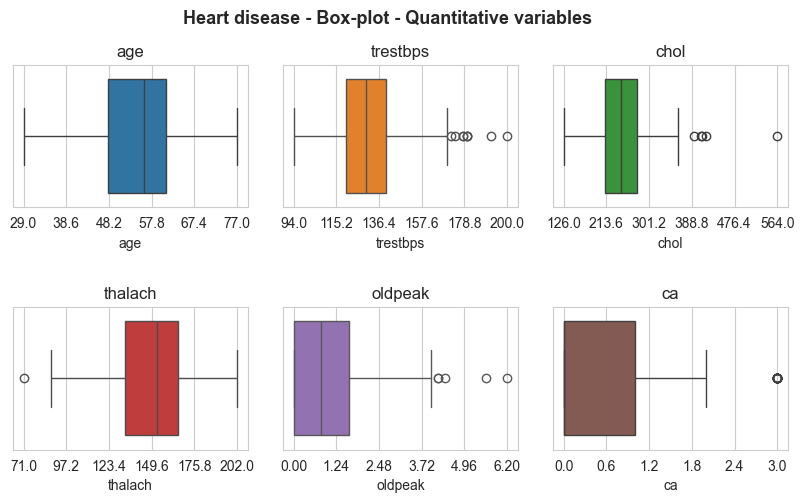

In [7]:
# Boxplot after outliers contamination
boxplot_matrix(X, 
               n_cols=3, 
               title=f'{formatted_data_name} - Box-plot - Quantitative variables', 
               figsize=(10,5), 
               quant_col_names=quant_predictors, 
               n_xticks=6, 
               title_fontsize=13, 
               save=False, 
               file_name='', 
               x_rotation=0, 
               title_height=0.99,
               style='whitegrid', 
               hspace=0.7, 
               wspace=0.15, 
               title_weight='bold',
               subtitles_fontsize=12, 
               xlabel_size=10)

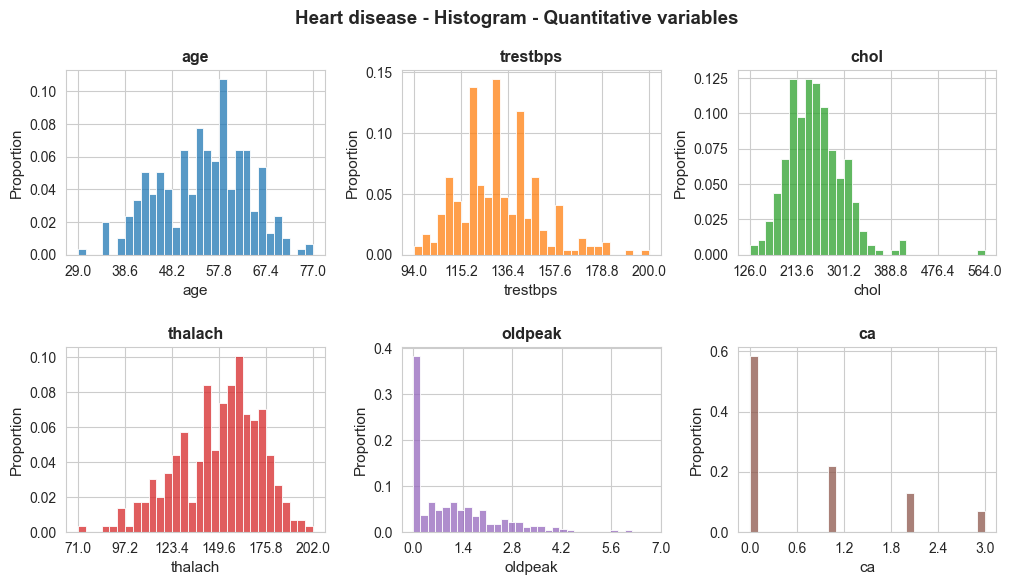

In [8]:
# Histogram
histogram_matrix(df=X, bins=30, n_cols=3, 
                 title=f'{formatted_data_name} - Histogram - Quantitative variables', 
                 figsize=(12,6), quant_col_names=quant_predictors, 
                 n_xticks=6, title_fontsize=13.5, 
                 subtitles_fontsize=11.5, save=False, file_name='', x_rotation=0, title_height=0.98,
                 style='whitegrid', hspace=0.5, wspace=0.3, n_round_xticks=1)

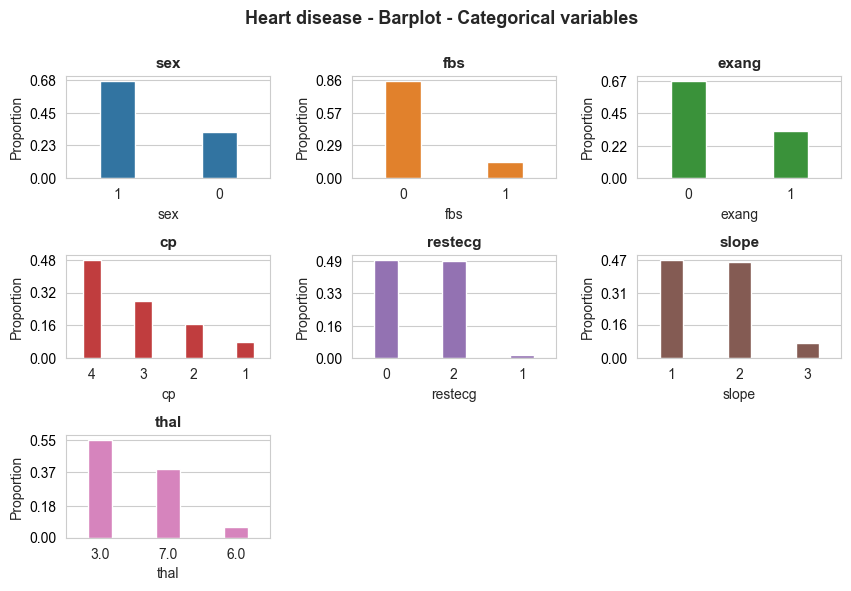

In [9]:
# Barplot
barplot_matrix(df=X, n_cols=3, 
               title=f'{formatted_data_name} - Barplot - Categorical variables', 
                 figsize=(10,6), cat_col_names=cat_predictors,
                 title_fontsize=13, subtitles_fontsize=11, 
                 save=False, file_name='', x_rotation=0, title_height=0.99,
                 style='whitegrid', hspace=0.75, wspace=0.4, title_weight='bold', bar_width=0.35,
                 ylabel_size=10, xlabel_size=10, xticks_size=10)

In [10]:
# Correlation Matrix
X[quant_predictors].corr()

age,trestbps,chol,thalach,oldpeak,ca
f64,f64,f64,f64,f64,f64
1.0,0.290476,0.202644,-0.394563,0.197123,0.36221
0.290476,1.0,0.131536,-0.049108,0.191243,0.097954
0.202644,0.131536,1.0,-0.000075,0.038596,0.115945
-0.394563,-0.049108,-0.000075,1.0,-0.34764,-0.268727
0.197123,0.191243,0.038596,-0.34764,1.0,0.294452
0.36221,0.097954,0.115945,-0.268727,0.294452,1.0


In [11]:
# Correlation Analysis
corr_matrix = X[quant_predictors].corr().to_numpy()
n_corr = len(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
n_corr_below_30 = np.sum(np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) < 0.30)
n_corr_above_60 = np.sum(np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) > 0.60)
n_corr_between = np.sum((np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) >= 0.30) & (np.abs(corr_matrix[np.triu_indices_from(corr_matrix, k=1)]) <= 0.60))
                        
print('Proportion of pair-wise correlation > 0.60 (in abs. value): ', np.round(n_corr_above_60 / n_corr, 2))
print('Proportion of pair-wise correlations in [0.30, 0.60]: ', np.round(n_corr_between / n_corr, 2))
print('Proportion of pair-wise correlation < 0.30 (in abs. value): ', np.round(n_corr_below_30 / n_corr, 2))

Proportion of pair-wise correlation > 0.60 (in abs. value):  0.0
Proportion of pair-wise correlations in [0.30, 0.60]:  0.2
Proportion of pair-wise correlation < 0.30 (in abs. value):  0.8


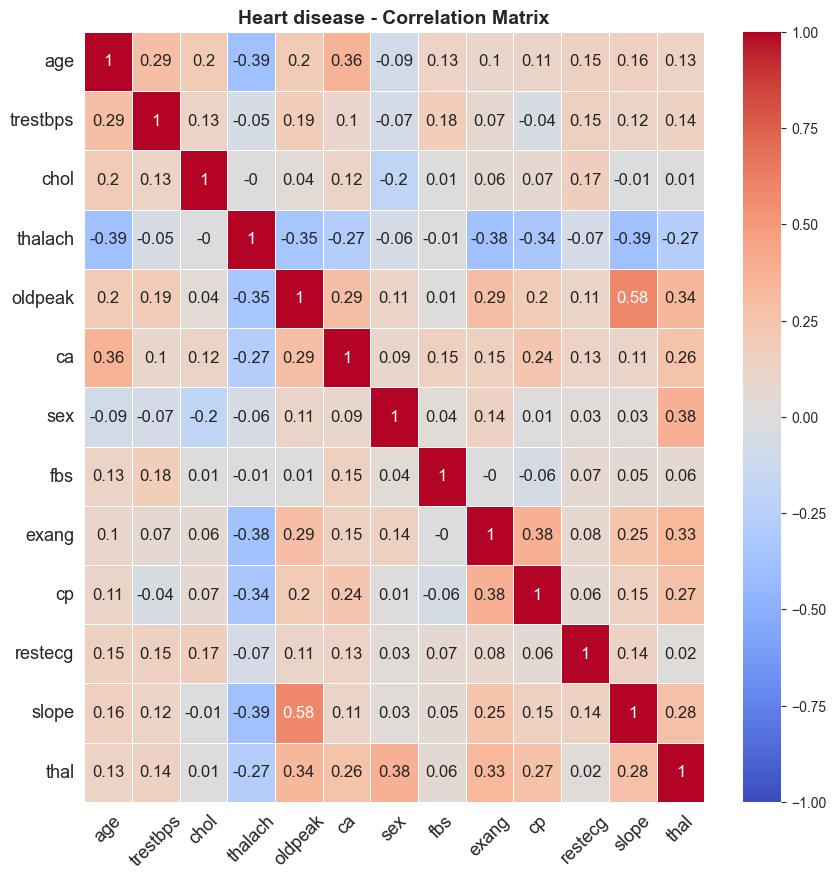

In [14]:
# Matriz de correlaciones
X_pd = X.to_pandas()
corr = X_pd.corr().round(2)

plt.figure(figsize=(10,10))
sns.heatmap(
    corr, 
    annot=True,                 # Muestra los valores dentro de las celdas
    cmap="coolwarm",            # Paleta de colores
    vmin=-1, vmax=1,             # Escala del colorbar
    linewidths=0.5,             # Líneas entre celdas
    annot_kws={"size": 12}      # Tamaño del texto dentro de las celdas
)

# Personalizar etiquetas
plt.xticks(fontsize=13, rotation=45)         # Tamaño etiquetas eje X
plt.yticks(fontsize=13, rotation=0)  # Tamaño etiquetas eje Y (sin rotación)
plt.title(f"{formatted_data_name} - Correlation Matrix", fontsize=14, fontweight='bold')
plt.show()
